In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")
train_df.columns

Index(['song_id', 'song_title', 'artist_id', 'artist_name', 'lyrics',
       'language', 'is_misogynistic', 'type_sexualization', 'type_violence',
       'type_hate', 'has_gender_stereotype'],
      dtype='str')

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Fixed categorical colors (consistent meaning across every chart in this notebook)
COLOR_M = "#2a78d6"       # misogynistic (M)
COLOR_NM = "#eb6834"      # not misogynistic (NM)
COLOR_ES = "#2a78d6"      # Spain
COLOR_LATAM = "#eb6834"   # Latin America
GRID_COLOR = "#e1e0d9"
AXIS_COLOR = "#c3c2b7"
TEXT_COLOR = "#0b0b0b"
MUTED_COLOR = "#898781"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "text.color": TEXT_COLOR,
    "xtick.color": MUTED_COLOR,
    "ytick.color": MUTED_COLOR,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

train_df = train_df.assign(split="train")
test_df = test_df.assign(split="test")
df = pd.concat([train_df, test_df], ignore_index=True)

LANGUAGE_LABELS = {"es_ES": "Spain", "es_LATAM": "Latin America"}
df["country"] = df["language"].map(LANGUAGE_LABELS)

df.head(3)

,song_id,song_title,artist_id,artist_name,lyrics,language,is_misogynistic,type_sexualization,type_violence,type_hate,has_gender_stereotype,split,country
0,4175,Rompe,294,Daddy Yankee,You know\nLos capos están ready\nLas mamis est...,es_LATAM,M,1.0,0.0,0.0,Y,train,Latin America
1,87563,Me Estás Tentando,381,Wisin & Yandel,La Mente Maestra\nHace rato que tu mirada me a...,es_LATAM,M,1.0,0.0,0.0,Y,train,Latin America
2,90914,Obsesión,548,Aventura (Ft. Judy Santos),"Something flavored, Aventura\nHello?\nShh, sol...",es_LATAM,M,1.0,0.0,0.0,Y,train,Latin America


## 1. M / NM distribution by dataset split

Counts:


is_misogynistic,M,NM
split,,
test,252,324
train,1009,1294



Percentage within split:


is_misogynistic,M,NM
split,,
test,43.75,56.25
train,43.81,56.19


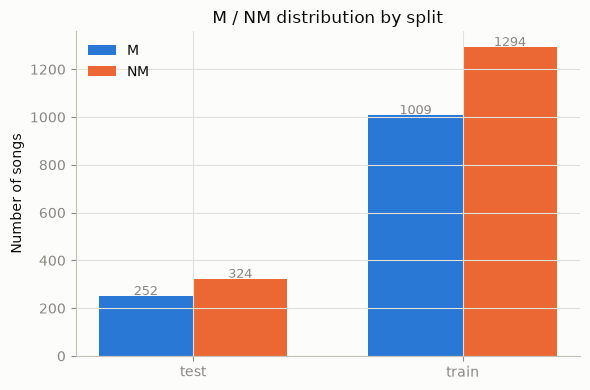

In [4]:
split_counts = pd.crosstab(df["split"], df["is_misogynistic"])
split_pct = pd.crosstab(df["split"], df["is_misogynistic"], normalize="index") * 100

print("Counts:")
display(split_counts)
print("\nPercentage within split:")
display(split_pct.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
splits = split_pct.index.tolist()
x = range(len(splits))
width = 0.35
ax.bar([i - width / 2 for i in x], split_counts["M"], width, label="M", color=COLOR_M)
ax.bar([i + width / 2 for i in x], split_counts["NM"], width, label="NM", color=COLOR_NM)
ax.set_xticks(list(x))
ax.set_xticklabels(splits)
ax.set_ylabel("Number of songs")
ax.set_title("M / NM distribution by split")
ax.legend(frameon=False)
for i, s in enumerate(splits):
    ax.text(i - width / 2, split_counts.loc[s, "M"] + 3, str(split_counts.loc[s, "M"]), ha="center", color=MUTED_COLOR, fontsize=9)
    ax.text(i + width / 2, split_counts.loc[s, "NM"] + 3, str(split_counts.loc[s, "NM"]), ha="center", color=MUTED_COLOR, fontsize=9)
plt.tight_layout()
plt.show()

### 1.1 M / NM distribution by country of origin (per split)

Counts:


is_misogynistic        M   NM
split country                
test  Latin America  137  159
      Spain          115  165
train Latin America  557  624
      Spain          452  670


Percentage within split/country:


is_misogynistic          M     NM
split country                    
test  Latin America  46.28  53.72
      Spain          41.07  58.93
train Latin America  47.16  52.84
      Spain          40.29  59.71

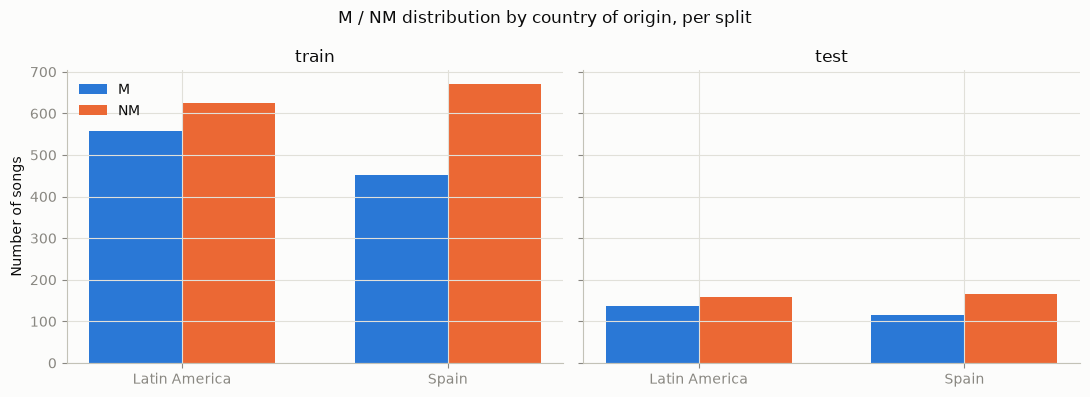

In [5]:
country_split_counts = pd.crosstab([df["split"], df["country"]], df["is_misogynistic"])
country_split_pct = pd.crosstab([df["split"], df["country"]], df["is_misogynistic"], normalize="index") * 100

print("Counts:")
display(country_split_counts)
print("\nPercentage within split/country:")
display(country_split_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, split_name in zip(axes, ["train", "test"]):
    sub = country_split_counts.loc[split_name]
    countries = sub.index.tolist()
    x = range(len(countries))
    width = 0.35
    ax.bar([i - width / 2 for i in x], sub["M"], width, label="M", color=COLOR_M)
    ax.bar([i + width / 2 for i in x], sub["NM"], width, label="NM", color=COLOR_NM)
    ax.set_xticks(list(x))
    ax.set_xticklabels(countries)
    ax.set_title(f"{split_name}")
axes[0].set_ylabel("Number of songs")
axes[0].legend(frameon=False)
fig.suptitle("M / NM distribution by country of origin, per split")
plt.tight_layout()
plt.show()

## 2. Misogyny type: statistical summary (songs where `is_misogynistic == "M"`)

`type_sexualization`, `type_violence`, and `type_hate` are only populated for misogynistic songs, and are not mutually exclusive (a song can carry more than one type).

Misogynistic (M) songs: 1261


,type_sexualization,type_violence,type_hate
count,1261.000000,1261.000000,1261.000000
mean,0.799366,0.311657,0.583664
std,0.400634,0.463354,0.493146
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


,count_present,pct_of_M_songs
type_sexualization,1008.0,79.94
type_violence,393.0,31.17
type_hate,736.0,58.37


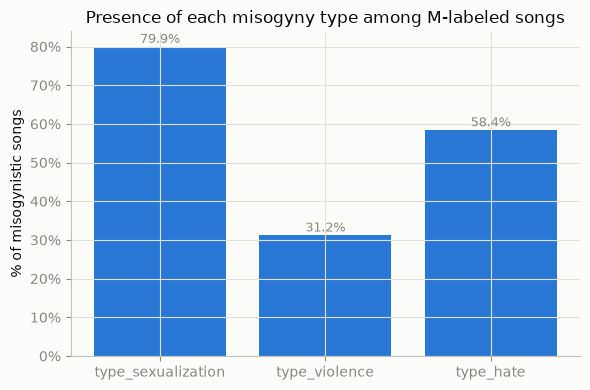

In [6]:
TYPE_COLS = ["type_sexualization", "type_violence", "type_hate"]

misogynistic_df = df[df["is_misogynistic"] == "M"]

print(f"Misogynistic (M) songs: {len(misogynistic_df)}")
display(misogynistic_df[TYPE_COLS].describe())

type_presence = pd.DataFrame({
    "count_present": misogynistic_df[TYPE_COLS].sum(),
    "pct_of_M_songs": (misogynistic_df[TYPE_COLS].mean() * 100).round(2),
})
display(type_presence)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(type_presence.index, type_presence["pct_of_M_songs"], color=COLOR_M)
ax.set_ylabel("% of misogynistic songs")
ax.set_title("Presence of each misogyny type among M-labeled songs")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for i, v in enumerate(type_presence["pct_of_M_songs"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", color=MUTED_COLOR, fontsize=9)
plt.tight_layout()
plt.show()

### 2.1 Misogyny type presence by country of origin

,type_sexualization,type_violence,type_hate
country,,,
Latin America,76.66,34.58,59.80
Spain,83.95,26.98,56.61


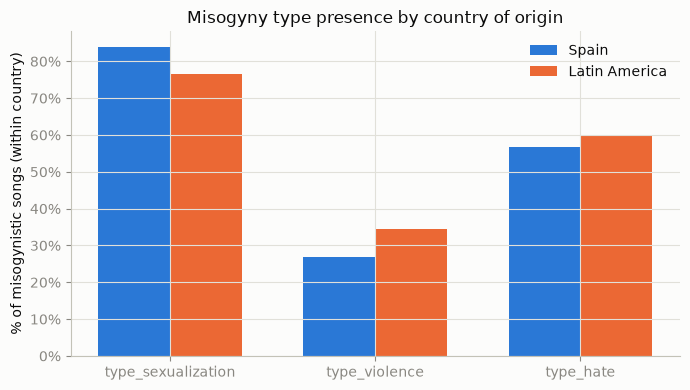

In [7]:
type_by_country = (misogynistic_df.groupby("country")[TYPE_COLS].mean() * 100).round(2)
display(type_by_country)

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(TYPE_COLS))
width = 0.35
es = type_by_country.loc["Spain"]
latam = type_by_country.loc["Latin America"]
ax.bar([i - width / 2 for i in x], es, width, label="Spain", color=COLOR_ES)
ax.bar([i + width / 2 for i in x], latam, width, label="Latin America", color=COLOR_LATAM)
ax.set_xticks(list(x))
ax.set_xticklabels(TYPE_COLS)
ax.set_ylabel("% of misogynistic songs (within country)")
ax.set_title("Misogyny type presence by country of origin")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. Gender stereotype: statistical summary (songs where `is_misogynistic == "M"`)

`has_gender_stereotype` is also only populated for misogynistic songs.

Counts:


has_gender_stereotype
Y    859
N    402
Name: count, dtype: int64


Percentage of M songs:


has_gender_stereotype
Y    68.12
N    31.88
Name: proportion, dtype: float64

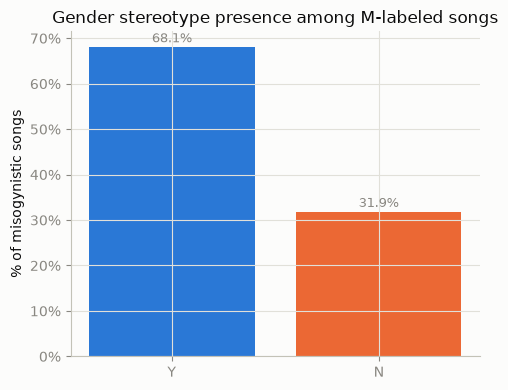

In [8]:
stereotype_counts = misogynistic_df["has_gender_stereotype"].value_counts()
stereotype_pct = (misogynistic_df["has_gender_stereotype"].value_counts(normalize=True) * 100).round(2)

print("Counts:")
display(stereotype_counts)
print("\nPercentage of M songs:")
display(stereotype_pct)

fig, ax = plt.subplots(figsize=(5, 4))
categories = ["Y", "N"]
values = [stereotype_pct.get(c, 0) for c in categories]
ax.bar(categories, values, color=[COLOR_M, COLOR_NM])
ax.set_ylabel("% of misogynistic songs")
ax.set_title("Gender stereotype presence among M-labeled songs")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for i, v in enumerate(values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", color=MUTED_COLOR, fontsize=9)
plt.tight_layout()
plt.show()

### 3.1 Gender stereotype presence by country of origin

Counts:


has_gender_stereotype,N,Y
country,,
Latin America,175,519
Spain,227,340



Percentage within country:


has_gender_stereotype,N,Y
country,,
Latin America,25.22,74.78
Spain,40.04,59.96


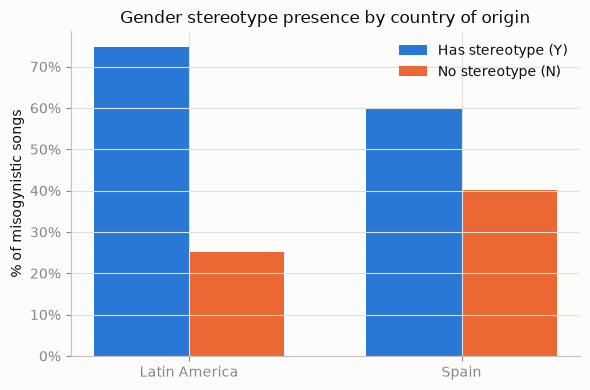

In [9]:
stereotype_by_country = pd.crosstab(misogynistic_df["country"], misogynistic_df["has_gender_stereotype"])
stereotype_by_country_pct = pd.crosstab(misogynistic_df["country"], misogynistic_df["has_gender_stereotype"], normalize="index") * 100

print("Counts:")
display(stereotype_by_country)
print("\nPercentage within country:")
display(stereotype_by_country_pct.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
countries = stereotype_by_country_pct.index.tolist()
x = range(len(countries))
width = 0.35
ax.bar([i - width / 2 for i in x], stereotype_by_country_pct["Y"], width, label="Has stereotype (Y)", color=COLOR_M)
ax.bar([i + width / 2 for i in x], stereotype_by_country_pct["N"], width, label="No stereotype (N)", color=COLOR_NM)
ax.set_xticks(list(x))
ax.set_xticklabels(countries)
ax.set_ylabel("% of misogynistic songs")
ax.set_title("Gender stereotype presence by country of origin")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 4. Lyrics length: statistical summary

Length is measured both in characters and in words.

In [10]:
df["lyrics_char_len"] = df["lyrics"].str.len()
df["lyrics_word_len"] = df["lyrics"].str.split().str.len()

print("Overall:")
display(df[["lyrics_char_len", "lyrics_word_len"]].describe().round(2))

print("\nBy split:")
display(df.groupby("split")[["lyrics_char_len", "lyrics_word_len"]].describe().round(2))

print("\nBy M/NM label:")
display(df.groupby("is_misogynistic")[["lyrics_char_len", "lyrics_word_len"]].describe().round(2))

print("\nBy country of origin:")
display(df.groupby("country")[["lyrics_char_len", "lyrics_word_len"]].describe().round(2))

Overall:


,lyrics_char_len,lyrics_word_len
count,2879.00,2879.00
mean,1788.31,346.15
std,1069.74,202.71
min,25.00,5.00
25%,1033.50,201.00
50%,1567.00,306.00
75%,2277.00,444.00
max,12213.00,2258.00



By split:


lyrics_char_len                                                    \
                count     mean      std    min     25%     50%      75%   
split                                                                     
test            576.0  1742.53  1057.91  187.0  1002.5  1496.5  2250.75   
train          2303.0  1799.76  1072.61   25.0  1048.0  1581.0  2281.50   

               lyrics_word_len                                              \
           max           count    mean     std   min    25%    50%     75%   
split                                                                        
test    9756.0           576.0  338.54  199.91  34.0  193.0  295.5  439.25   
train  12213.0          2303.0  348.05  203.41   5.0  202.5  308.0  446.00   

               
          max  
split          
test   1616.0  
train  2258.0


By M/NM label:


lyrics_char_len                                           \
                          count     mean      std    min     25%     50%   
is_misogynistic                                                            
M                        1261.0  2217.95  1125.23  250.0  1465.0  2090.0   
NM                       1618.0  1453.47   891.08   25.0   883.0  1256.5   

                                 lyrics_word_len                               \
                    75%      max           count    mean     std   min    25%   
is_misogynistic                                                                 
M                2713.0  12213.0          1261.0  427.42  213.39  54.0  279.0   
NM               1780.0  10131.0          1618.0  282.81  168.79   5.0  173.0   

                                       
                   50%    75%     max  
is_misogynistic                        
M                402.0  525.0  2258.0  
NM               247.0  345.0  1965.0


By country of origin:


lyrics_char_len                                           \
                        count     mean      std    min     25%     50%   
country                                                                  
Latin America          1477.0  1668.23  1095.00   25.0   922.0  1370.0   
Spain                  1402.0  1914.81  1027.79  187.0  1213.5  1756.0   

                                lyrics_word_len                               \
                   75%      max           count    mean     std   min    25%   
country                                                                        
Latin America  2145.00  12213.0          1477.0  323.05  207.42   5.0  180.0   
Spain          2360.75   8546.0          1402.0  370.48  194.76  34.0  233.0   

                                     
                 50%    75%     max  
country                              
Latin America  269.0  418.0  2258.0  
Spain          335.5  461.0  1626.0

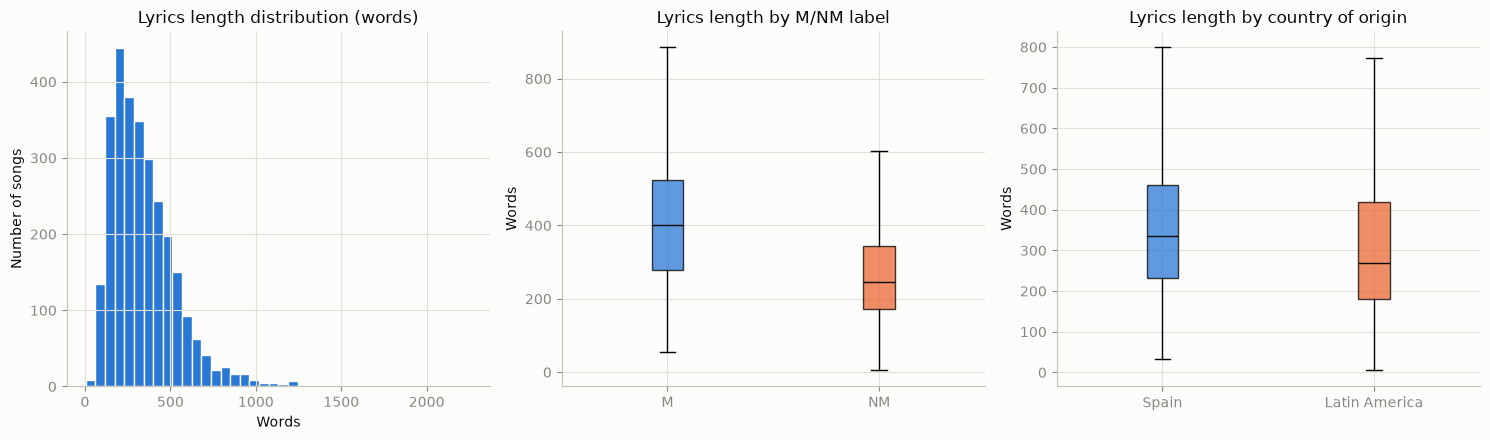

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(df["lyrics_word_len"], bins=40, color=COLOR_M, edgecolor="#fcfcfb")
axes[0].set_title("Lyrics length distribution (words)")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Number of songs")

def boxplot_by(ax, groups, labels, colors, title):
    bp = ax.boxplot(groups, tick_labels=labels, patch_artist=True, showfliers=False,
                     medianprops={"color": TEXT_COLOR})
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(title)
    ax.set_ylabel("Words")

boxplot_by(
    axes[1],
    [df.loc[df["is_misogynistic"] == c, "lyrics_word_len"] for c in ["M", "NM"]],
    ["M", "NM"], [COLOR_M, COLOR_NM],
    "Lyrics length by M/NM label",
)

boxplot_by(
    axes[2],
    [df.loc[df["country"] == c, "lyrics_word_len"] for c in ["Spain", "Latin America"]],
    ["Spain", "Latin America"], [COLOR_ES, COLOR_LATAM],
    "Lyrics length by country of origin",
)

plt.tight_layout()
plt.show()

### 4.1 Shortest lyrics (interactive browser)

Pick a word-count threshold (100 / 150 words, or type another value) and step through the matching songs one at a time with the slider.

In [12]:
import ipywidgets as widgets
from IPython.display import display


def get_short_lyrics(max_words):
    return (
        df[df["lyrics_word_len"] <= max_words]
        .sort_values("lyrics_word_len")
        .reset_index(drop=True)
    )


threshold_picker = widgets.Dropdown(
    options=[50, 100, 150, 200, 300],
    value=100,
    description="Max words:",
)
index_slider = widgets.IntSlider(min=0, max=0, step=1, description="Song #:", continuous_update=False)
counter_label = widgets.Label()
output = widgets.Output()


def refresh_slider(*_):
    n = len(get_short_lyrics(threshold_picker.value))
    index_slider.max = max(n - 1, 0)
    index_slider.value = 0
    show_song()


def show_song(*_):
    subset = get_short_lyrics(threshold_picker.value)
    counter_label.value = f"{len(subset)} songs with <= {threshold_picker.value} words"
    output.clear_output(wait=True)
    with output:
        if subset.empty:
            print("No songs found for this threshold.")
            return
        row = subset.iloc[index_slider.value]
        print(f"#{index_slider.value + 1} / {len(subset)}")
        print(f"song_id={row['song_id']}  split={row['split']}  country={row['country']}  "
              f"is_misogynistic={row['is_misogynistic']}  words={row['lyrics_word_len']}")
        print(f"{row['artist_name']} - {row['song_title']}")
        print("-" * 40)
        print(row["lyrics"])


threshold_picker.observe(refresh_slider, names="value")
index_slider.observe(show_song, names="value")

refresh_slider()
display(widgets.VBox([threshold_picker, counter_label, index_slider, output]))